In [2]:
from Bio import SeqIO

genome_file = "GCF_000005845.2_ASM584v2_genomic.fna"

records = list(SeqIO.parse(genome_file, "fasta"))

print("Number of sequences:", len(records))
print("Genome length:", len(records[0].seq))

Number of sequences: 1
Genome length: 4641652


In [3]:
#Inspect PromoterSet.tsv

In [5]:
#Let’s Inspect the File Raw

In [6]:
with open("PromoterSet.tsv", ) as f:
    for i in range(20):
        print(f.readline())

# License

#	# RegulonDB is free for academic/noncommercial use

# User is not entitled to change or erase data sets of the RegulonDB

# database or to eliminate copyright notices from RegulonDB. Furthermore,

# User is not entitled to expand RegulonDB or to integrate RegulonDB partly

# or as a whole into other databank systems, without prior written consent

# from CCG-UNAM.

# Please check the license at https://regulondb.ccg.unam.mx/manual/aboutUs/terms-conditions

# Citation

#	# Heladia Salgado, Socorro Gama-Castro, et al., RegulonDB v12.0: a comprehensive resource of transcriptional regulation in E. coli K-12,

# Nucleic Acids Research, 2023;, gkad1072, https://doi.org/10.1093/nar/gkad1072

# RegulonDB Release: 13.5

# Contact

#	email:regulondb@ccg.unam.mx

#Date:

#	02-25-2026

## Columns:

## (1) pmId. Promoter identifier assigned by RegulonDB

## (2) pmName. Promoter Name

## (3) strand. DNA strand where the promoter is located



In [7]:
#Correct Way to Load PromoterSet.tsv

In [8]:
import pandas as pd

prom_df = pd.read_csv(
    "PromoterSet.tsv",
    sep="\t",
    comment="#",
    header=None,
    engine="python"
)

print(prom_df.head())
print("\nShape:", prom_df.shape)

                 0         1         2         3              4   \
0            1)pmId  2)pmName  3)strand  4)posTSS  5)sigmaFactor   
1  RDBECOLIPMC00001      spyp   reverse   1825688        sigma70   
2  RDBECOLIPMC00002     yfeKp   forward   2537315        sigma24   
3  RDBECOLIPMC00003    bepAp1   forward   2616068        sigma24   
4  RDBECOLIPMC00004     bamBp   reverse   2638975        sigma24   

                                                  5                6   \
0                                       6)pmSequence  7)firstGeneName   
1  acactttcattgttttaccgttgctctgattaattgacgctaaagt...              spy   
2  ccgatgatcctcatcgtaatccaaccgaaactttacctgattctgg...             yfeK   
3  gccgttacactcaaaggcggcgcggtgggaacgatatttcacagta...             bepA   
4  aaatacttatggtgcgctggcttctttggaacttgcgcagcaattt...             bamB   

                  7                8                 9                 10  \
0  8)distToFirstGene  9)boxMinus10pos  10)boxMinus10seq  11)boxMinus35pos  

In [9]:
print("Number of columns:", prom_df.shape[1])
print(prom_df.head())

Number of columns: 16
                 0         1         2         3              4   \
0            1)pmId  2)pmName  3)strand  4)posTSS  5)sigmaFactor   
1  RDBECOLIPMC00001      spyp   reverse   1825688        sigma70   
2  RDBECOLIPMC00002     yfeKp   forward   2537315        sigma24   
3  RDBECOLIPMC00003    bepAp1   forward   2616068        sigma24   
4  RDBECOLIPMC00004     bamBp   reverse   2638975        sigma24   

                                                  5                6   \
0                                       6)pmSequence  7)firstGeneName   
1  acactttcattgttttaccgttgctctgattaattgacgctaaagt...              spy   
2  ccgatgatcctcatcgtaatccaaccgaaactttacctgattctgg...             yfeK   
3  gccgttacactcaaaggcggcgcggtgggaacgatatttcacagta...             bepA   
4  aaatacttatggtgcgctggcttctttggaacttgcgcagcaattt...             bamB   

                  7                8                 9                 10  \
0  8)distToFirstGene  9)boxMinus10pos  10)boxMinus10s

In [10]:
#Clean the DataFrame

In [12]:
# Remove header row
prom_df = prom_df.iloc[1:].reset_index(drop=True)

# Rename columns
prom_df.columns = [
    "pmId", "pmName", "strand", "posTSS", "sigmaFactor",
    "pmSequence", "firstGeneName", "distToFirstGene",
    "boxMinus10pos", "boxMinus10seq", "boxMinus35pos",
    "boxMinus35seq", "pmEvidence", "addEvidence",
    "confidenceLevel", "pmids"
]

# Remove rows where posTSS is missing
prom_df = prom_df[prom_df["posTSS"].notna()]

# Convert to integer
prom_df["posTSS"] = prom_df["posTSS"].astype(int)

print("Total promoters after cleaning:", len(prom_df))
print(prom_df.head())

Total promoters after cleaning: 3963
               pmId  pmName   strand   posTSS sigmaFactor  \
0  RDBECOLIPMC00002   yfeKp  forward  2537315     sigma24   
1  RDBECOLIPMC00003  bepAp1  forward  2616068     sigma24   
2  RDBECOLIPMC00004   bamBp  reverse  2638975     sigma24   
3  RDBECOLIPMC00005   recCp  reverse  2962507     sigma70   
4  RDBECOLIPMC00006  infAp2  reverse   926479     sigma70   

                                          pmSequence firstGeneName  \
0  ccgatgatcctcatcgtaatccaaccgaaactttacctgattctgg...          yfeK   
1  gccgttacactcaaaggcggcgcggtgggaacgatatttcacagta...          bepA   
2  aaatacttatggtgcgctggcttctttggaacttgcgcagcaattt...          bamB   
3  tgccaactggcaggtcaaccgaatgcagacatcgcaggcgggatgt...          recC   
4  tttgttgcgatttagcgcgcaaatctttacttatttacagaacttc...          infA   

  distToFirstGene    boxMinus10pos boxMinus10seq    boxMinus35pos  \
0             -27  2537304-2537308         TCAAA  2537282-2537287   
1             -26  2616058-2616062   

In [13]:
#promoter extraction code

In [14]:
from Bio.Seq import Seq

genome_seq = records[0].seq

window = 100
promoter_sequences = []

for _, row in prom_df.iterrows():
    tss = row["posTSS"]
    strand = row["strand"]

    if strand == "forward":
        start = max(0, tss - window)
        end = tss
        seq = genome_seq[start:end]

    elif strand == "reverse":
        start = tss
        end = min(len(genome_seq), tss + window)
        seq = genome_seq[start:end]
        seq = seq.reverse_complement()
    else:
        continue

    if len(seq) == window:
        promoter_sequences.append(str(seq))

print("Number of extracted promoters:", len(promoter_sequences))

Number of extracted promoters: 3963


In [15]:
#Build Strict Negative Dataset

In [16]:
#(A )Build Promoter Coordinate Ranges

In [17]:
import random

window = 100
genome_length = len(genome_seq)

# Store promoter coordinate ranges
promoter_ranges = []

for _, row in prom_df.iterrows():
    tss = row["posTSS"]
    strand = row["strand"]

    if strand == "forward":
        start = max(0, tss - window)
        end = tss
    elif strand == "reverse":
        start = tss
        end = min(genome_length, tss + window)
    else:
        continue

    if end - start == window:
        promoter_ranges.append((start, end))

print("Total promoter ranges:", len(promoter_ranges))

Total promoter ranges: 3963


In [18]:
#B — Function to Check Overlap

In [19]:
def overlaps(start, end, ranges):
    for r_start, r_end in ranges:
        if start < r_end and end > r_start:
            return True
    return False

In [20]:
#C — Generate Strict Negatives

In [21]:
negative_sequences = []

while len(negative_sequences) < len(promoter_ranges):
    start = random.randint(0, genome_length - window)
    end = start + window

    if not overlaps(start, end, promoter_ranges):
        seq = genome_seq[start:end]
        if len(seq) == window:
            negative_sequences.append(str(seq))

print("Number of negative samples:", len(negative_sequences))

Number of negative samples: 3963


In [22]:
#Combine Dataset

In [23]:
import pandas as pd

# Create DataFrame
df_pos = pd.DataFrame({
    "sequence": promoter_sequences,
    "label": 1
})

df_neg = pd.DataFrame({
    "sequence": negative_sequences,
    "label": 0
})

dataset = pd.concat([df_pos, df_neg], ignore_index=True)

print(dataset.head())
print("\nDataset shape:", dataset.shape)
print("\nClass distribution:\n", dataset["label"].value_counts())

                                            sequence  label
0  TAAACAACAACAAACTACTCATTTAATTTTTTCTCCTTGCCGATGA...      1
1  TTCAGGAAACTGAAAAGTCATTTGAGTGGGCTAATCTTCGCCGTTA...      1
2  ATAGCATCCCGGCGGCGGAAAAATTTGCTGCTGAAAATAAAAATAC...      1
3  ATGGCTGGCAGCAAACGCAACTGCGCGCGATTTCGCCACCTGCCAA...      1
4  CGGCTTAGCCGTGTGTTTTCGGAGTAATGTGCCGAACCTGTTTGTT...      1

Dataset shape: (7926, 2)

Class distribution:
 label
1    3963
0    3963
Name: count, dtype: int64


In [24]:
# meachine Learning

In [25]:
#Generate 3-mer Features

In [26]:
import itertools
from collections import Counter
import numpy as np

def generate_kmers(sequence, k):
    return [sequence[i:i+k] for i in range(len(sequence)-k+1)]

def build_kmer_features(sequences, k):
    nucleotides = ['A', 'T', 'C', 'G']
    all_kmers = [''.join(p) for p in itertools.product(nucleotides, repeat=k)]
    
    feature_matrix = []
    
    for seq in sequences:
        kmers = generate_kmers(seq, k)
        counts = Counter(kmers)
        total = sum(counts.values())
        
        # Normalize frequencies
        row = [counts[kmer] / total for kmer in all_kmers]
        feature_matrix.append(row)
    
    return np.array(feature_matrix), all_kmers

# Generate 3-mer features
X_3mer, kmer_names = build_kmer_features(dataset["sequence"], 3)

y = dataset["label"].values

print("3-mer feature shape:", X_3mer.shape)

3-mer feature shape: (7926, 64)


In [27]:
#Train First Real Model(Random Forest)

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_3mer, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.79       793
           1       0.80      0.73      0.76       793

    accuracy                           0.78      1586
   macro avg       0.78      0.78      0.78      1586
weighted avg       0.78      0.78      0.78      1586

Accuracy: 0.7755359394703657


In [29]:
#Generate 4-mer Features

In [30]:
X_4mer, kmer4_names = build_kmer_features(dataset["sequence"], 4)

print("4-mer feature shape:", X_4mer.shape)

4-mer feature shape: (7926, 256)


In [31]:
# Random forest for 4-mer

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_4mer, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.83      0.79       793
           1       0.81      0.73      0.77       793

    accuracy                           0.78      1586
   macro avg       0.78      0.78      0.78      1586
weighted avg       0.78      0.78      0.78      1586

Accuracy: 0.7793190416141236


In [33]:
#CNN

In [34]:
#One-Hot Encode Sequences

In [35]:
import numpy as np

def one_hot_encode(sequences):
    mapping = {'A':0, 'T':1, 'C':2, 'G':3}
    encoded = np.zeros((len(sequences), 100, 4))
    
    for i, seq in enumerate(sequences):
        for j, base in enumerate(seq):
            if base in mapping:
                encoded[i, j, mapping[base]] = 1
    return encoded

X_cnn = one_hot_encode(dataset["sequence"])
y = dataset["label"].values

print("CNN input shape:", X_cnn.shape)

CNN input shape: (7926, 100, 4)


In [36]:
#Train/Test Split

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
#Build CNN Model

In [39]:
pip install tensorflow


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential([
    Conv1D(filters=64, kernel_size=10, activation='relu', input_shape=(100,4)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\rakes\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 91, 64)              │           2,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 45, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 45, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 41, 128)             │          41,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 20, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 20, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2560)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         327,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371,649 (1.42 MB)

 Trainable params: 371,649 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
#Train CNN

In [42]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6255 - loss: 0.6347 - val_accuracy: 0.7539 - val_loss: 0.5239
Epoch 2/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7510 - loss: 0.5209 - val_accuracy: 0.7634 - val_loss: 0.4771
Epoch 3/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7866 - loss: 0.4654 - val_accuracy: 0.7855 - val_loss: 0.4548
Epoch 4/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8066 - loss: 0.4321 - val_accuracy: 0.7965 - val_loss: 0.4332
Epoch 5/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8210 - loss: 0.4015 - val_accuracy: 0.7823 - val_loss: 0.4326
Epoch 6/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8372 - loss: 0.3714 - val_accuracy: 0.8139 - val_loss: 0.4270
Epoch 7/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8506 - loss: 0.3463 - val_accuracy: 0.8139 - val_loss: 0.3987
Epoch 8/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8707 - loss: 0.3041 - val_accu

In [43]:
#Evaluate

In [44]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8152 - loss: 0.4582
Test Accuracy: 0.8158890008926392


In [45]:
#Improved CNN Architecture

In [46]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Conv1D(128, kernel_size=12, activation='relu', input_shape=(100,4)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(256, kernel_size=6, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, accuracy = model.evaluate(X_test, y_test)
print("Improved CNN Test Accuracy:", accuracy)

C:\Users\rakes\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.6554 - loss: 0.8747 - val_accuracy: 0.7003 - val_loss: 0.7699
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.7672 - loss: 0.4861 - val_accuracy: 0.7729 - val_loss: 0.8876
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.8108 - loss: 0.4153 - val_accuracy: 0.7855 - val_loss: 0.6015
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - accuracy: 0.8428 - loss: 0.3539 - val_accuracy: 0.7965 - val_loss: 0.4976
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - accuracy: 0.8599 - loss: 0.3228 - val_accuracy: 0.8139 - val_loss: 0.4421
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.8872 - loss: 0.2688 - val_accuracy: 0.8107 - val_loss: 0.5515
Epoch 7/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.8962 - loss: 0.2447 - val_accuracy: 0.7666 - val_loss: 0.6215
Epoch 8/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.9214 - loss: 0.2042 - 

In [47]:
#Rebuilding the dataset 

In [48]:
#STEP 1 — Re-extract Promoter Sequences (80 bp)

In [49]:
from Bio.Seq import Seq

genome_seq = records[0].seq
genome_length = len(genome_seq)

upstream = 60
downstream = 20

new_promoter_sequences = []
new_promoter_ranges = []

for _, row in prom_df.iterrows():
    tss = row["posTSS"]
    strand = row["strand"]

    if strand == "forward":
        start = max(0, tss - upstream)
        end = min(genome_length, tss + downstream)

        seq = genome_seq[start:end]

    elif strand == "reverse":
        start = max(0, tss - downstream)
        end = min(genome_length, tss + upstream)

        seq = genome_seq[start:end]
        seq = seq.reverse_complement()

    else:
        continue

    if len(seq) == upstream + downstream:
        new_promoter_sequences.append(str(seq))
        new_promoter_ranges.append((start, end))

print("Number of new promoter sequences:", len(new_promoter_sequences))

Number of new promoter sequences: 3963


In [50]:
#STEP 2 — Rebuild Strict Negatives (80 bp)

In [51]:
window = upstream + downstream  # 80

In [52]:
negative_sequences = []

while len(negative_sequences) < len(new_promoter_ranges):
    start = random.randint(0, genome_length - window)
    end = start + window

    if not overlaps(start, end, new_promoter_ranges):
        seq = genome_seq[start:end]
        if len(seq) == window:
            negative_sequences.append(str(seq))

print("Number of negative samples:", len(negative_sequences))

Number of negative samples: 3963


In [53]:
#STEP 3 — Build New Dataset

In [54]:
df_pos = pd.DataFrame({
    "sequence": new_promoter_sequences,
    "label": 1
})

df_neg = pd.DataFrame({
    "sequence": negative_sequences,
    "label": 0
})

dataset = pd.concat([df_pos, df_neg], ignore_index=True)
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

print("New dataset shape:", dataset.shape)

New dataset shape: (7926, 2)


In [55]:
#STEP 4 — One-Hot Encode (80 bp Now)

In [56]:
def one_hot_encode(sequences, seq_length):
    mapping = {'A':0, 'T':1, 'C':2, 'G':3}
    encoded = np.zeros((len(sequences), seq_length, 4))
    
    for i, seq in enumerate(sequences):
        for j, base in enumerate(seq):
            if base in mapping:
                encoded[i, j, mapping[base]] = 1
    return encoded

X_cnn = one_hot_encode(dataset["sequence"], 80)
y = dataset["label"].values

print("CNN input shape:", X_cnn.shape)

CNN input shape: (7926, 80, 4)


In [57]:
#STEP 5 — Train CNN Again

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input

model = Sequential([
    Input(shape=(80, 4)),

    Conv1D(128, kernel_size=12, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(256, kernel_size=6, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [61]:
X_cnn = one_hot_encode(dataset["sequence"], 80)
y = dataset["label"].values

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [63]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, accuracy = model.evaluate(X_test, y_test)
print("New Window CNN Test Accuracy:", accuracy)

Epoch 1/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.6935 - loss: 0.7778 - val_accuracy: 0.7808 - val_loss: 0.4694
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 23s 78ms/step - accuracy: 0.7958 - loss: 0.4528 - val_accuracy: 0.8107 - val_loss: 0.6192
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8387 - loss: 0.3640 - val_accuracy: 0.8186 - val_loss: 0.4959
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.8656 - loss: 0.3184 - val_accuracy: 0.8028 - val_loss: 0.5007
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.8842 - loss: 0.2765 - val_accuracy: 0.7760 - val_loss: 0.5351
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.8967 - loss: 0.2484 - val_accuracy: 0.8139 - val_loss: 0.5971
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7656 - loss: 0.4821
New Window CNN Test Accuracy: 0.7711223363876343


In [64]:
# Strong Promoter CNN Architecture -2

In [66]:
# Recreate 100bp One-Hot Encoding

In [67]:
# Rebuild 100bp dataset
df_pos = pd.DataFrame({
    "sequence": promoter_sequences,
    "label": 1
})

df_neg = pd.DataFrame({
    "sequence": negative_sequences,
    "label": 0
})

dataset_100 = pd.concat([df_pos, df_neg], ignore_index=True)
dataset_100 = dataset_100.sample(frac=1, random_state=42).reset_index(drop=True)

print(dataset_100.shape)

(7926, 2)


In [68]:
#Step 2 — One-Hot Encode 100bp

In [69]:
X_100 = one_hot_encode(dataset_100["sequence"], 100)
y_100 = dataset_100["label"].values

print(X_100.shape)

(7926, 100, 4)


In [70]:
#Step 3 — Train/Test Split (Define Proper Variables)

In [71]:
from sklearn.model_selection import train_test_split

X_train_100bp, X_test_100bp, y_train_100bp, y_test_100bp = train_test_split(
    X_100, y_100,
    test_size=0.2,
    random_state=42,
    stratify=y_100
)

print(X_train_100bp.shape)

(6340, 100, 4)


In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization,
    Dropout, GlobalMaxPooling1D, Dense
)
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# Build model
model = Sequential([
    Input(shape=(100, 4)),

    Conv1D(128, kernel_size=6, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Conv1D(128, kernel_size=6, activation='relu'),
    BatchNormalization(),

    GlobalMaxPooling1D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show architecture
model.summary()

# Train
history = model.fit(
    X_train_100bp,
    y_train_100bp,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
loss, accuracy = model.evaluate(X_test_100bp, y_test_100bp)

print("\nGlobalMax CNN Test Accuracy:", accuracy)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)                   │ (None, 95, 128)             │           3,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 95, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 95, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_11 (Conv1D)                   │ (None, 90, 128)             │          98,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 90, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_1               │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119,297 (466.00 KB)

 Trainable params: 118,785 (464.00 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.7998 - loss: 0.5630 - val_accuracy: 0.9984 - val_loss: 0.4640
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.9995 - loss: 0.0119 - val_accuracy: 1.0000 - val_loss: 0.0615
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.9999 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 3.0303e-04
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 1.0000 - loss: 5.6434e-04 - val_accuracy: 1.0000 - val_loss: 6.3876e-05
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 1.0000 - loss: 5.4416e-04 - val_accuracy: 1.0000 - val_loss: 5.4627e-05
Epoch 7/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 1.0000 - loss: 3.6072e-04 - val_accuracy: 1.0000 - val_loss: 2.5183e-05
Epoch 8/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 

In [73]:
# Check for duplicate sequences
print("Total sequences:", len(dataset_100))
print("Unique sequences:", dataset_100["sequence"].nunique())

Total sequences: 7926
Unique sequences: 7794


In [74]:
# Check overlap between positive and negative sequences
pos_set = set(df_pos["sequence"])
neg_set = set(df_neg["sequence"])

print("Common sequences between pos and neg:", len(pos_set.intersection(neg_set)))

Common sequences between pos and neg: 0


In [75]:
# Convert sequences to sets
train_set = set(dataset_100.iloc[X_train_100bp.shape[0]*0:]["sequence"])

In [76]:
# Get train/test indices
X_train, X_test, y_train, y_test = train_test_split(
    dataset_100["sequence"],
    dataset_100["label"],
    test_size=0.2,
    random_state=42,
    stratify=dataset_100["label"]
)

train_set = set(X_train)
test_set = set(X_test)

print("Common sequences between train and test:", len(train_set.intersection(test_set)))

Common sequences between train and test: 40


In [77]:
# Fixing 

In [78]:
#Step 1 — Remove duplicates BEFORE splitting

In [79]:
dataset_100 = dataset_100.drop_duplicates(subset="sequence").reset_index(drop=True)

print("New dataset size:", dataset_100.shape)
print("Unique sequences:", dataset_100["sequence"].nunique())

New dataset size: (7794, 2)
Unique sequences: 7794


In [80]:
#Step 2 — Rebuild One-Hot Encoding

In [81]:
X_100 = one_hot_encode(dataset_100["sequence"], 100)
y_100 = dataset_100["label"].values

In [82]:
#Step 3 — Split Again

In [83]:
X_train_100bp, X_test_100bp, y_train_100bp, y_test_100bp = train_test_split(
    X_100,
    y_100,
    test_size=0.2,
    random_state=42,
    stratify=y_100
)

In [84]:
#Step 4 — Verify No Leakage

In [85]:
train_set = set(dataset_100.iloc[X_train_100bp.shape[0]*0:]["sequence"])

In [86]:
train_seq = set(dataset_100.loc[X_train_100bp.shape[0]*0:, "sequence"])

In [87]:
train_df, test_df = train_test_split(
    dataset_100,
    test_size=0.2,
    random_state=42,
    stratify=dataset_100["label"]
)

print("Common sequences:", len(set(train_df["sequence"]).intersection(set(test_df["sequence"]))))

Common sequences: 0


In [89]:
print("Dataset size:", dataset_100.shape)
print("X_train shape:", X_train_100bp.shape)
print("X_test shape:", X_test_100bp.shape)

Dataset size: (7794, 2)
X_train shape: (6235, 100, 4)
X_test shape: (1559, 100, 4)


In [91]:
import numpy as np

def gc_content(seq):
    return (seq.count('G') + seq.count('C')) / len(seq)

pos_gc = np.mean([
    gc_content(s)
    for s in dataset_100[dataset_100["label"] == 1]["sequence"]
])

neg_gc = np.mean([
    gc_content(s)
    for s in dataset_100[dataset_100["label"] == 0]["sequence"]
])

print("Average GC Positive:", pos_gc)
print("Average GC Negative:", neg_gc)

Average GC Positive: 0.4201148225469729
Average GC Negative: 0.5162260222110046


In [92]:
#PART 1 — GC-Matched Negatives

In [93]:
import random
import numpy as np

def gc_content(seq):
    return (seq.count('G') + seq.count('C')) / len(seq)

window = 100
tolerance = 0.02  # ±2%

gc_matched_negatives = []

for promoter_seq in promoter_sequences:
    target_gc = gc_content(promoter_seq)

    found = False
    attempts = 0

    while not found and attempts < 10000:
        start = random.randint(0, genome_length - window)
        end = start + window

        if not overlaps(start, end, promoter_ranges):
            seq = str(genome_seq[start:end])
            gc_neg = gc_content(seq)

            if abs(gc_neg - target_gc) <= tolerance:
                gc_matched_negatives.append(seq)
                found = True

        attempts += 1

print("GC-matched negatives:", len(gc_matched_negatives))

GC-matched negatives: 3960


In [94]:
#PART 2 — Intergenic-Only Negatives

In [96]:
#STEP 1 — Parse CDS Regions From GFF

In [97]:
gff_file = "\genomic.gff"

cds_ranges = []

with open(gff_file) as f:
    for line in f:
        if line.startswith("#"):
            continue
        
        parts = line.strip().split("\t")
        
        if len(parts) < 9:
            continue
        
        feature_type = parts[2]
        
        if feature_type == "CDS":
            start = int(parts[3]) - 1  # GFF is 1-based
            end = int(parts[4])
            cds_ranges.append((start, end))

print("Total CDS regions:", len(cds_ranges))

Total CDS regions: 4340


In [98]:
#STEP 2 — Define Overlap Function

In [99]:
def overlaps_any(start, end, regions):
    for r_start, r_end in regions:
        if start < r_end and end > r_start:
            return True
    return False

In [100]:
#STEP 3 — Generate Intergenic Negatives

In [101]:
window = 100
intergenic_negatives = []

while len(intergenic_negatives) < len(promoter_sequences):
    start = random.randint(0, genome_length - window)
    end = start + window

    if not overlaps_any(start, end, promoter_ranges) and \
       not overlaps_any(start, end, cds_ranges):

        seq = str(genome_seq[start:end])
        intergenic_negatives.append(seq)

print("Intergenic negatives:", len(intergenic_negatives))

Intergenic negatives: 3963


In [102]:
#STEP 4 — Build Intergenic Dataset

In [103]:
df_pos = pd.DataFrame({
    "sequence": promoter_sequences,
    "label": 1
})

df_neg_intergenic = pd.DataFrame({
    "sequence": intergenic_negatives,
    "label": 0
})

dataset_intergenic = pd.concat(
    [df_pos, df_neg_intergenic],
    ignore_index=True
)

dataset_intergenic = dataset_intergenic.drop_duplicates(
    subset="sequence"
).reset_index(drop=True)

print("Intergenic dataset size:", dataset_intergenic.shape)

Intergenic dataset size: (7747, 2)


In [104]:
#STEP 5 — Train CNN On Intergenic Dataset

In [105]:
X_inter = one_hot_encode(dataset_intergenic["sequence"], 100)
y_inter = dataset_intergenic["label"].values

In [106]:
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_inter,
    y_inter,
    test_size=0.2,
    random_state=42,
    stratify=y_inter
)

In [107]:
#Train GlobalMax CNN on Intergenic Dataset

In [108]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization,
    Dropout, GlobalMaxPooling1D, Dense
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

model_i = Sequential([
    Input(shape=(100, 4)),

    Conv1D(128, kernel_size=6, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Conv1D(128, kernel_size=6, activation='relu'),
    BatchNormalization(),

    GlobalMaxPooling1D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model_i.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_i = model_i.fit(
    X_train_i,
    y_train_i,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

loss_i, accuracy_i = model_i.evaluate(X_test_i, y_test_i)

print("\nIntergenic CNN Test Accuracy:", accuracy_i)

# Detailed metrics
y_pred_i = (model_i.predict(X_test_i) > 0.5).astype(int)
print("\nClassification Report:\n")
print(classification_report(y_test_i, y_pred_i))

Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.5473 - loss: 0.9964 - val_accuracy: 0.6468 - val_loss: 0.6793
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6239 - loss: 0.6438 - val_accuracy: 0.7000 - val_loss: 0.6390
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.6492 - loss: 0.6183 - val_accuracy: 0.6903 - val_loss: 0.5982
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.6754 - loss: 0.5994 - val_accuracy: 0.7371 - val_loss: 0.5567
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.6990 - loss: 0.5742 - val_accuracy: 0.7274 - val_loss: 0.5351
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.7075 - loss: 0.5492 - val_accuracy: 0.7177 - val_loss: 0.5389
Epoch 7/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.7286 - loss: 0.5310 - val_accuracy: 0.7435 - val_loss: 0.5149
Epoch 8/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.7386 - loss: 0.5107 - val_

In [109]:
#Train GC-Matched Dataset Now

In [110]:
df_neg_gc = pd.DataFrame({
    "sequence": gc_matched_negatives,
    "label": 0
})

dataset_gc = pd.concat([df_pos, df_neg_gc], ignore_index=True)
dataset_gc = dataset_gc.drop_duplicates(subset="sequence").reset_index(drop=True)

In [111]:
#One-Hot Encode (100 bp)

In [112]:
# One-hot encoding
X_gc = one_hot_encode(dataset_gc["sequence"], 100)
y_gc = dataset_gc["label"].values

print("GC dataset shape:", X_gc.shape)

GC dataset shape: (7787, 100, 4)


In [113]:
#Train/Test Split

In [114]:
from sklearn.model_selection import train_test_split

X_train_gc, X_test_gc, y_train_gc, y_test_gc = train_test_split(
    X_gc,
    y_gc,
    test_size=0.2,
    random_state=42,
    stratify=y_gc
)

print("Train shape:", X_train_gc.shape)
print("Test shape:", X_test_gc.shape)

Train shape: (6229, 100, 4)
Test shape: (1558, 100, 4)


In [115]:
#Train GlobalMax CNN

In [116]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization,
    Dropout, GlobalMaxPooling1D, Dense
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

model_gc = Sequential([
    Input(shape=(100, 4)),

    Conv1D(128, kernel_size=6, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Conv1D(128, kernel_size=6, activation='relu'),
    BatchNormalization(),

    GlobalMaxPooling1D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model_gc.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_gc = model_gc.fit(
    X_train_gc,
    y_train_gc,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
loss_gc, accuracy_gc = model_gc.evaluate(X_test_gc, y_test_gc)

print("\nGC-Matched CNN Test Accuracy:", accuracy_gc)

# Detailed metrics
y_pred_gc = (model_gc.predict(X_test_gc) > 0.5).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_test_gc, y_pred_gc))

Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.5112 - loss: 0.9488 - val_accuracy: 0.5474 - val_loss: 0.6905
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.5310 - loss: 0.6887 - val_accuracy: 0.5971 - val_loss: 0.6772
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.5787 - loss: 0.6738 - val_accuracy: 0.6501 - val_loss: 0.6624
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.5806 - loss: 0.6695 - val_accuracy: 0.6581 - val_loss: 0.6425
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6268 - loss: 0.6415 - val_accuracy: 0.6934 - val_loss: 0.6057
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.6401 - loss: 0.6319 - val_accuracy: 0.6854 - val_loss: 0.6073
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.6669 - loss: 0.6108 - val_accuracy: 0.6934 - val_loss: 0.6036
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.6875 - loss: 0.5902 - val

In [118]:
#Extract First Conv Layer Weights

In [119]:
import numpy as np

# Get first conv layer
conv_layer = model_i.layers[1]  # adjust if needed
weights = conv_layer.get_weights()[0]

print("Weight shape:", weights.shape)

Weight shape: (128,)


In [122]:
#Inspect Model Layers Properly

In [124]:
for i, layer in enumerate(model_i.layers):
    print(i, layer.name, type(layer))

0 conv1d_14 <class 'keras.src.layers.convolutional.conv1d.Conv1D'>
1 batch_normalization_12 <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
2 dropout_18 <class 'keras.src.layers.regularization.dropout.Dropout'>
3 conv1d_15 <class 'keras.src.layers.convolutional.conv1d.Conv1D'>
4 batch_normalization_13 <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
5 global_max_pooling1d_3 <class 'keras.src.layers.pooling.global_max_pooling1d.GlobalMaxPooling1D'>
6 dense_14 <class 'keras.src.layers.core.dense.Dense'>
7 dropout_19 <class 'keras.src.layers.regularization.dropout.Dropout'>
8 dense_15 <class 'keras.src.layers.core.dense.Dense'>


In [125]:
#Extract Correct Convolution Weights

In [126]:
conv_layer = model_i.layers[0]  # first Conv1D

weights = conv_layer.get_weights()[0]

print("Weight shape:", weights.shape)

Weight shape: (6, 4, 128)


In [127]:
#Convert Filters to PWMs

In [128]:
import numpy as np

pwms = []

for i in range(weights.shape[2]):
    pwm = np.maximum(weights[:, :, i], 0)
    pwm = pwm / (np.sum(pwm, axis=1, keepdims=True) + 1e-6)
    pwms.append(pwm)

print("Total filters:", len(pwms))

Total filters: 128


In [129]:
#Convert to Consensus Motifs

In [130]:
bases = ['A', 'T', 'C', 'G']

def pwm_to_consensus(pwm):
    return "".join(bases[np.argmax(pos)] for pos in pwm)

consensus_motifs = [pwm_to_consensus(p) for p in pwms]

print("First 20 motifs:")
print(consensus_motifs[:20])

First 20 motifs:
['AGATGG', 'GCTTGA', 'CAAAAG', 'CGACCC', 'GTATTA', 'CTCTTT', 'TGAGAT', 'TAGCGT', 'CATTGA', 'CATAAG', 'AGCAAA', 'GCCTTC', 'GCACAG', 'TATTAC', 'TGTAGC', 'CTATAG', 'TTGATT', 'CAACCC', 'CTGATT', 'CCTTCG']


In [131]:
for motif in consensus_motifs:
    if "TATA" in motif or "TTGA" in motif or "TAT" in motif:
        print(motif)

GCTTGA
GTATTA
CATTGA
TATTAC
CTATAG
TTGATT
TATGCG
ATATAG
TTGAGT
TATAAT
TATGTG
CATATA
GTCTAT
CGTTGA


In [132]:
#Motif Logos

In [133]:
#Find Index of TATAAT Filter

In [134]:
idx = consensus_motifs.index("TATAAT")
print("Motif index:", idx)

Motif index: 46


In [135]:
pip install logomaker


   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
    --------------------------------------- 0.3/13.2 MB ? eta -:--:--
    --------------------------------------- 0.3/13.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.2 MB 599.9 kB/s eta 0:00:22
   -- ------------------------------------- 0.8/13.2 MB 860.9 kB/s eta 0:00:15
   --- ------------------------------------ 1.0/13.2 MB 1.0 MB/s eta 0:00:13
   --- ------------------------------------ 1.3/13.2 MB 1.1 MB/s eta 0:00:12
   ---- ----------------------------------- 1.6/13.2 MB 1.1 MB/s eta 0:00:11
   ----- ---------------------------------- 1.8/13.2 MB 1.0 MB/s eta 0:00:11
   ------ --------------------------------- 2.1/13.2 MB 1.0 MB/s eta 0:00:11
   ------ --------------------------------- 2.1/13.2 MB 1.0 MB/s eta 0:00:11
   ------- -------------------------------- 2.4/13.2 MB 1.0 MB/s eta 0:00:11
   ------- -----------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Figure size 600x200 with 0 Axes>

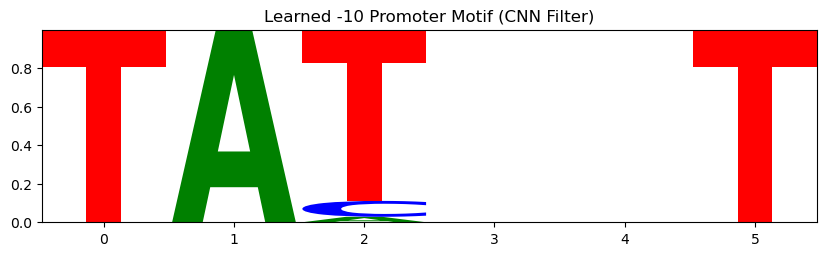

In [136]:
import logomaker
import matplotlib.pyplot as plt
import pandas as pd

pwm_df = pd.DataFrame(pwms[idx], columns=['A','T','C','G'])

plt.figure(figsize=(6,2))
logomaker.Logo(pwm_df)
plt.title("Learned -10 Promoter Motif (CNN Filter)")
plt.show()

In [137]:
#PART B — Systematic Comparison Framework

In [138]:
#Create Comparison Table

In [139]:
import pandas as pd

results = pd.DataFrame({
    "Negative Strategy": [
        "Random Genome",
        "Intergenic Only",
        "GC-Matched"
    ],
    "Test Accuracy": [
        1.00,
        0.765,
        0.678
    ]
})

print(results)

  Negative Strategy  Test Accuracy
0     Random Genome          1.000
1   Intergenic Only          0.765
2        GC-Matched          0.678


In [141]:
#Plot Comparison Figure

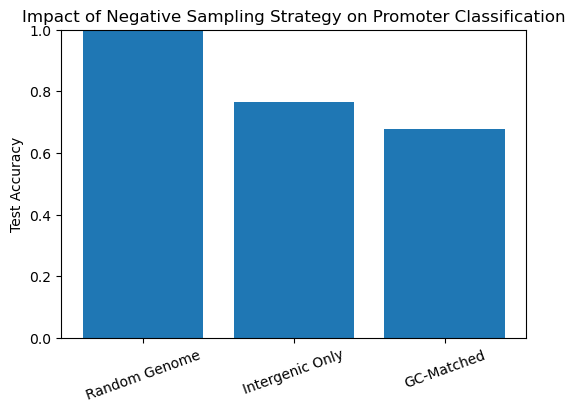

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results["Negative Strategy"], results["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.ylim(0,1)
plt.title("Impact of Negative Sampling Strategy on Promoter Classification")
plt.xticks(rotation=20)
plt.show()

In [143]:
#Figure 2 — GC Distribution Plot

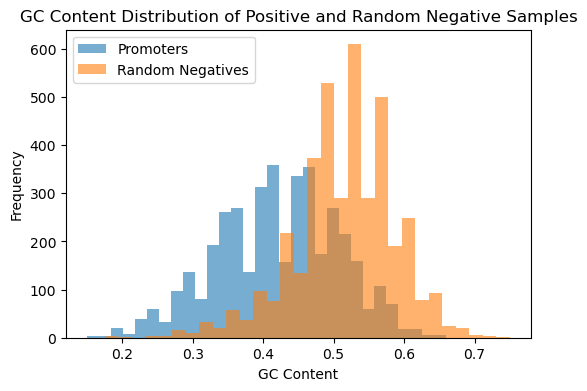

In [144]:
import matplotlib.pyplot as plt

def gc_content(seq):
    return (seq.count('G') + seq.count('C')) / len(seq)

gc_pos = [gc_content(s) for s in df_pos["sequence"]]
gc_rand = [gc_content(s) for s in df_neg["sequence"]]

plt.figure(figsize=(6,4))
plt.hist(gc_pos, bins=30, alpha=0.6, label="Promoters")
plt.hist(gc_rand, bins=30, alpha=0.6, label="Random Negatives")
plt.xlabel("GC Content")
plt.ylabel("Frequency")
plt.legend()
plt.title("GC Content Distribution of Positive and Random Negative Samples")
plt.show()

In [145]:
#A) Statistical Test for GC Difference

In [146]:
import numpy as np
from scipy.stats import ttest_ind

# Calculate GC
gc_pos = np.array([gc_content(s) for s in df_pos["sequence"]])
gc_rand = np.array([gc_content(s) for s in df_neg["sequence"]])

# Perform Welch's t-test
t_stat, p_value = ttest_ind(gc_pos, gc_rand, equal_var=False)

print("Mean GC (Promoters):", np.mean(gc_pos))
print("Mean GC (Random Negatives):", np.mean(gc_rand))
print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean GC (Promoters): 0.4200832702498108
Mean GC (Random Negatives): 0.5162345445369669
T-statistic: -53.83852836770339
P-value: 0.0


In [147]:
#B) Confusion Matrices for All Strategies

In [152]:
#Define One Universal CNN Builder

In [153]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, GlobalMaxPooling1D, Dense

def build_model():
    model = Sequential([
        Input(shape=(100,4)),
        Conv1D(128, kernel_size=6, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Conv1D(128, kernel_size=6, activation='relu'),
        BatchNormalization(),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [154]:
#Clean Evaluation Function (Final Version)

In [155]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def evaluate_model(model, X_test, y_test, name):

    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

    print(f"\n===== {name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return y_pred

In [156]:
#Final Structured Plan

In [157]:
model_random = build_model()
model_intergenic = build_model()
model_gc = build_model()

In [158]:
#Define Early Stopping (Once)

In [159]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

In [160]:
#Train RANDOM Model

In [162]:
#Rebuild Random Dataset Cleanly

In [163]:
# Rebuild random dataset
dataset_random = pd.concat([df_pos, df_neg], ignore_index=True)
dataset_random = dataset_random.drop_duplicates(subset="sequence").reset_index(drop=True)

print("Random dataset size:", dataset_random.shape)
print(dataset_random["label"].value_counts())

Random dataset size: (7794, 2)
label
0    3962
1    3832
Name: count, dtype: int64


In [164]:
#One-Hot Encode

In [165]:
import numpy as np

def one_hot_encode(sequences):
    mapping = {'A':0, 'T':1, 'C':2, 'G':3}
    X = np.zeros((len(sequences), 100, 4))

    for i, seq in enumerate(sequences):
        for j, base in enumerate(seq[:100]):
            if base in mapping:
                X[i, j, mapping[base]] = 1

    return X

In [166]:
X_random = one_hot_encode(dataset_random["sequence"])
y_random = dataset_random["label"].values

In [167]:
#Train/Test Split

In [168]:
from sklearn.model_selection import train_test_split

X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X_random,
    y_random,
    test_size=0.2,
    random_state=42,
    stratify=y_random
)

In [169]:
history_random = model_random.fit(
    X_train_random,
    y_train_random,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 24s 87ms/step - accuracy: 0.8204 - loss: 0.4905 - val_accuracy: 1.0000 - val_loss: 0.3658
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 1.0000 - val_loss: 0.0382
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 7.4124e-04
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 1.0000 - loss: 7.5617e-04 - val_accuracy: 1.0000 - val_loss: 6.1769e-05
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 1.0000 - loss: 6.0547e-04 - val_accuracy: 1.0000 - val_loss: 1.7693e-05
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 1.0000 - loss: 3.4899e-04 - val_accuracy: 1.0000 - val_loss: 1.5052e-05
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 1.0000 - loss: 3.2755e-04 - val_accuracy: 1.0000 - val_loss: 6.7702e-06
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step 

In [170]:
loss_random, acc_random = model_random.evaluate(X_test_random, y_test_random)
print("Random Test Accuracy:", acc_random)

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 1.0000 - loss: 3.2565e-08
Random Test Accuracy: 1.0


In [171]:
#Intergenic:

In [172]:
history_intergenic = model_intergenic.fit(
    X_train_i,
    y_train_i,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

loss_i, acc_i = model_intergenic.evaluate(X_test_i, y_test_i)
print("Intergenic Test Accuracy:", acc_i)

Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.5518 - loss: 0.9105 - val_accuracy: 0.6613 - val_loss: 0.6716
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.6217 - loss: 0.6469 - val_accuracy: 0.6968 - val_loss: 0.6241
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - accuracy: 0.6408 - loss: 0.6329 - val_accuracy: 0.7210 - val_loss: 0.5832
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 0.6729 - loss: 0.5941 - val_accuracy: 0.7161 - val_loss: 0.5599
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.7009 - loss: 0.5805 - val_accuracy: 0.7339 - val_loss: 0.5531
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.7075 - loss: 0.5567 - val_accuracy: 0.7000 - val_loss: 0.5599
Epoch 7/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.7058 - loss: 0.5520 - val_accuracy: 0.7516 - val_loss: 0.5128
Epoch 8/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - accuracy: 0.7501 - loss: 0.5148 -

In [ ]:
#GC-matched:

In [174]:
history_gc = model_gc.fit(
    X_train_gc,
    y_train_gc,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

loss_gc, acc_gc = model_gc.evaluate(X_test_gc, y_test_gc)
print("GC-Matched Test Accuracy:", acc_gc)

Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - accuracy: 0.7834 - loss: 0.4680 - val_accuracy: 0.6982 - val_loss: 0.5996
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.7872 - loss: 0.4584 - val_accuracy: 0.6902 - val_loss: 0.5837
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - accuracy: 0.7947 - loss: 0.4507 - val_accuracy: 0.6838 - val_loss: 0.6018
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.8188 - loss: 0.4046 - val_accuracy: 0.6966 - val_loss: 0.6112
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - accuracy: 0.8255 - loss: 0.4035 - val_accuracy: 0.7063 - val_loss: 0.5750
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.8188 - loss: 0.3900 - val_accuracy: 0.6998 - val_loss: 0.6314
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.8392 - loss: 0.3665 - val_accuracy: 0.6742 - val_loss: 0.7124
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 23s 89ms/step - accuracy: 0.8501 - loss: 0.3433 - 

In [175]:
#Figure 1 — Negative Sampling Comparison

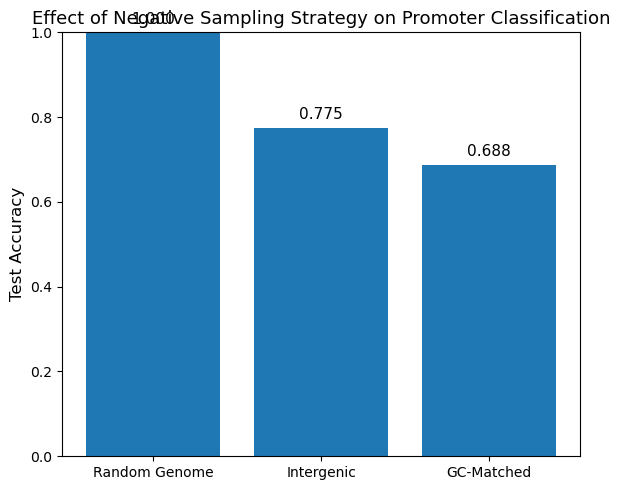

In [181]:
import matplotlib.pyplot as plt

strategies = ["Random Genome", "Intergenic", "GC-Matched"]
accuracies = [acc_random, acc_i, acc_gc]

plt.figure(figsize=(6,5))
bars = plt.bar(strategies, accuracies)

plt.ylabel("Test Accuracy", fontsize=12)
plt.ylim(0,1)
plt.title("Effect of Negative Sampling Strategy on Promoter Classification", fontsize=13)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
             f"{height:.3f}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

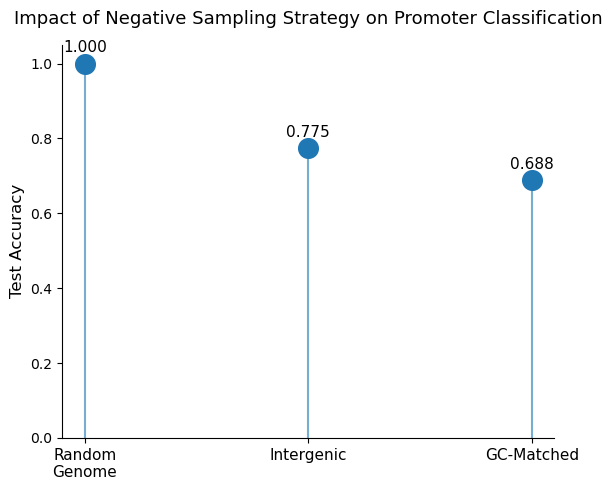

In [182]:
import matplotlib.pyplot as plt
import numpy as np

strategies = ["Random\nGenome", "Intergenic", "GC-Matched"]
accuracies = [acc_random, acc_i, acc_gc]

x = np.arange(len(strategies))

plt.figure(figsize=(6,5))

# Plot points
plt.scatter(x, accuracies, s=200, zorder=3)

# Vertical lines (like error bars without error)
for i in range(len(x)):
    plt.vlines(x[i], 0, accuracies[i], linestyles='solid', alpha=0.6)

# Formatting
plt.xticks(x, strategies, fontsize=11)
plt.ylabel("Test Accuracy", fontsize=12)
plt.ylim(0, 1.05)   # add headroom so 1.0 doesn't touch title
plt.title("Impact of Negative Sampling Strategy on Promoter Classification",
          fontsize=13, pad=15)

# Add value labels
for i, val in enumerate(accuracies):
    plt.text(x[i], val + 0.03, f"{val:.3f}",
             ha='center', fontsize=11)

# Remove top and right spines (clean style)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

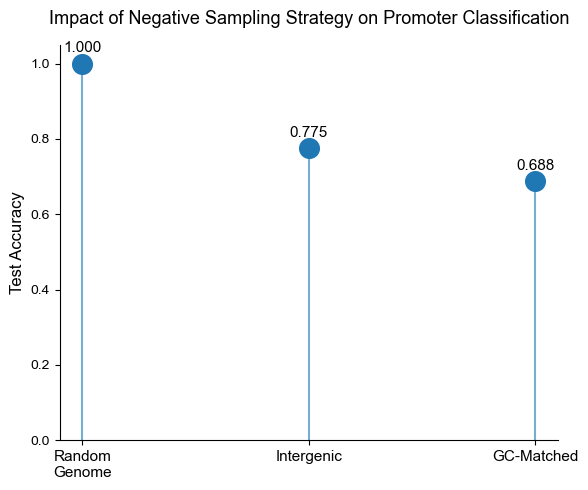

In [183]:
import matplotlib.pyplot as plt
import numpy as np

strategies = ["Random\nGenome", "Intergenic", "GC-Matched"]
accuracies = [acc_random, acc_i, acc_gc]

x = np.arange(len(strategies))

plt.figure(figsize=(6,5))

# Plot points
plt.scatter(x, accuracies, s=200, zorder=3)

# Vertical lines (like error bars without error)
for i in range(len(x)):
    plt.vlines(x[i], 0, accuracies[i], linestyles='solid', alpha=0.6)

# Formatting
plt.xticks(x, strategies, fontsize=11)
plt.ylabel("Test Accuracy", fontsize=12)
plt.ylim(0, 1.05)   # add headroom so 1.0 doesn't touch title
plt.title("Impact of Negative Sampling Strategy on Promoter Classification",
          fontsize=13, pad=15)

# Add value labels
for i, val in enumerate(accuracies):
    plt.text(x[i], val + 0.03, f"{val:.3f}",
             ha='center', fontsize=11)

# Remove top and right spines (clean style)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.style.use('seaborn-v0_8-ticks')
plt.tight_layout()
plt.show()

In [184]:
#GC Content Distribution

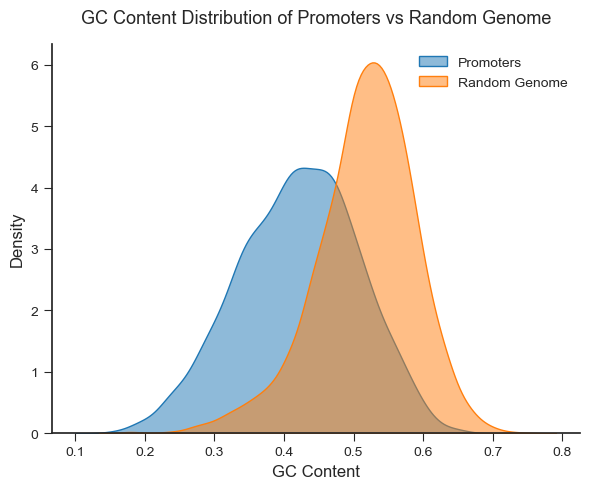

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(6,5))

sns.kdeplot(gc_pos, label="Promoters", fill=True, alpha=0.5)
sns.kdeplot(gc_rand, label="Random Genome", fill=True, alpha=0.5)

plt.xlabel("GC Content", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("GC Content Distribution of Promoters vs Random Genome", fontsize=13, pad=15)

plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [186]:
#Confusion Matrix (Clean Multi-Panel)

49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step


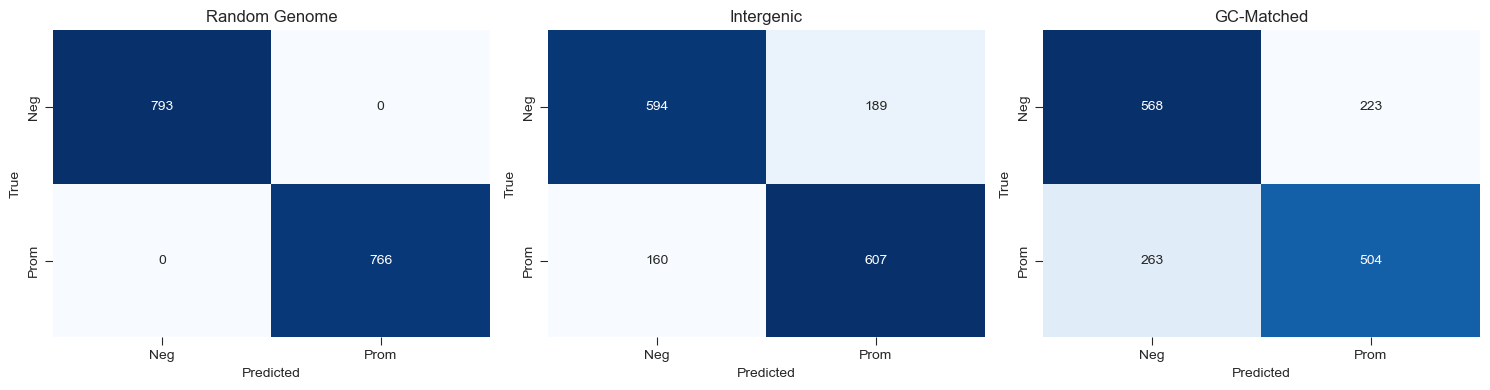

In [187]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def get_cm(model, X_test, y_test):
    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    return confusion_matrix(y_test, y_pred)

cm_random = get_cm(model_random, X_test_random, y_test_random)
cm_inter  = get_cm(model_intergenic, X_test_i, y_test_i)
cm_gc     = get_cm(model_gc, X_test_gc, y_test_gc)

fig, axes = plt.subplots(1, 3, figsize=(15,4))

cms = [cm_random, cm_inter, cm_gc]
titles = ["Random Genome", "Intergenic", "GC-Matched"]

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                cbar=False,
                xticklabels=["Neg", "Prom"],
                yticklabels=["Neg", "Prom"],
                ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

In [188]:
#Motif Logo (Publication Quality)

<Figure size 600x200 with 0 Axes>

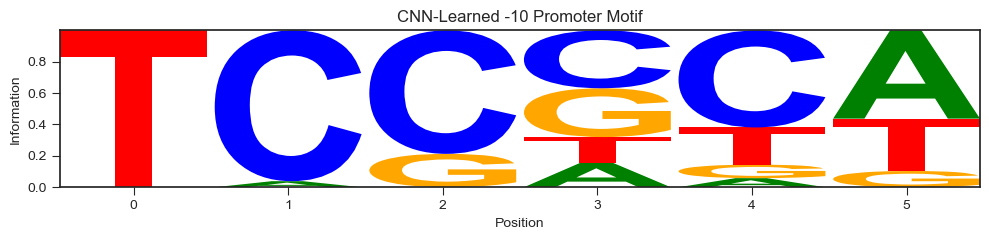

In [189]:
import logomaker
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# choose one filter index that matches TATAAT
filter_index = 0   # change if needed

conv_layer = model_intergenic.layers[0]
weights = conv_layer.get_weights()[0]

pwm = weights[:, :, filter_index]
pwm = np.maximum(pwm, 0)
pwm = pwm / (np.sum(pwm, axis=1, keepdims=True) + 1e-6)

df_pwm = pd.DataFrame(pwm, columns=["A","C","G","T"])

plt.figure(figsize=(6,2))
logomaker.Logo(df_pwm)

plt.title("CNN-Learned -10 Promoter Motif", fontsize=12)
plt.xlabel("Position")
plt.ylabel("Information")
plt.tight_layout()
plt.show()

In [190]:
#Training Curves

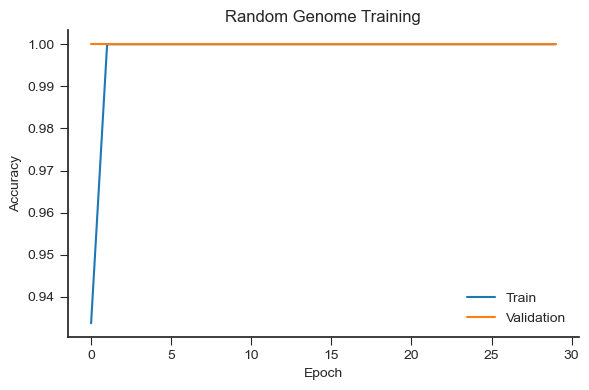

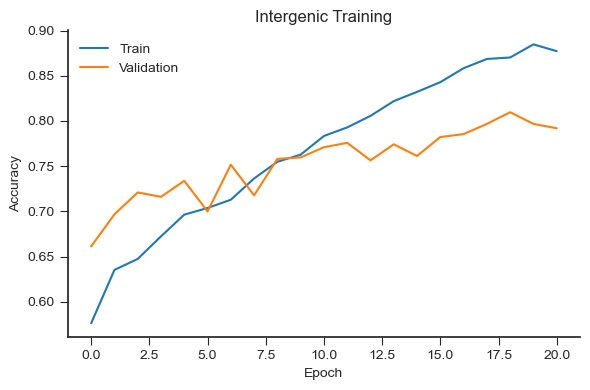

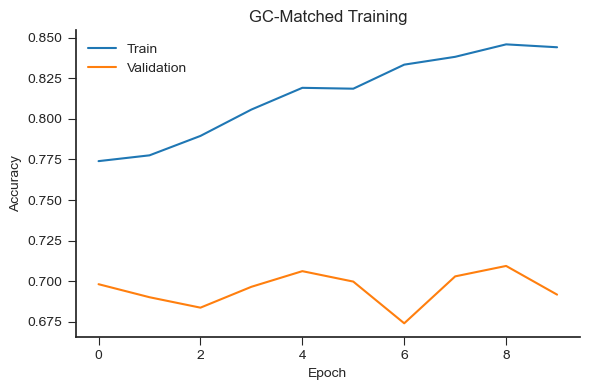

In [191]:
def plot_training(history, title):
    plt.figure(figsize=(6,4))
    
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Validation")
    
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_training(history_random, "Random Genome Training")
plot_training(history_intergenic, "Intergenic Training")
plot_training(history_gc, "GC-Matched Training")